# IBL Widefield — Raw Data Tutorial

This notebook shows how to stream and explore raw widefield imaging data from
[DANDI:001713](https://dandiarchive.org/dandiset/001713) (embargoed).

## Study Overview

This study provides a brain-wide survey of representations of prior information during mouse decision-making. Using a standardized task, the International Brain Laboratory (IBL) recorded activity across multiple brain regions while mice performed a perceptual decision-making task where the probability of a stimulus appearing on the left or right changed across blocks. This data contains the raw widefield imaging data used to analyze how prior expectations about the environment are represented across the cortex.

## Contents

1. [Setup and Data Access](#setup)
2. [Session and Subject Metadata](#metadata)
3. [Raw Imaging Data](#raw)
   - [OnePhotonSeries](#one-photon-series)
   - [Imaging Plane Metadata](#imaging-metadata)
4. [Synchronization Signals](#sync)
   - [Digital Events](#digital-signals)
   - [Analog Signals](#analog-signals)
5. [Behavior](#behavior)
   - [Epochs](#epochs)
   - [Raw Video](#raw-video)

---

## 1. Setup and Data Access <a id="setup"></a>

In [1]:
from itertools import cycle

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [ ]:
from .load_nwb_utils import *

dandiset_id = "001713"  # Embargoed IBL widefield dandiset
subject_id = "CSK-im-009"  # Example CSK subject — update as needed
session_id = "2864dca1-38d8-464c-9777-f6fdfd5e63b5"  # Example session EID

# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id, description="raw")
else:
    # TODO Specify your local directory path
    local_directory = f"E:/IBL-widefield-nwbfiles/full/"
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id, description="raw")

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 The neural representations of prior information about the state of the world are poorly understood. Here, to investigate them, we examined brain-wide Neuropixels recordings and widefield calcium imaging collected by the International Brain Laboratory. Mice were trained to indicate the location of a visual grating stimulus, which appeared on the left or right with a prior probability alternating between 0.2 and 0.8 in blocks of variable length. We found that mice estimate this prior probability and thereby improve their decision accuracy. Furthermore, we report that this subjective prior is encoded in at least 20% to 30% of brain regions, notably, that span all levels of processing, from early sensory areas (the lateral geniculate nucleus and primary visual cortex) to motor regions (secondary and primary motor cortex and gigantocellular reticular nucleus) and high-level cortical regions (the dorsal anterior cingulate area and ventrola

---

## 2. Session and Subject Metadata <a id="metadata"></a>

In [3]:
print("=== SESSION INFORMATION ===")
print(f"Session start time : {nwbfile.session_start_time}")
print(f"Session description: {nwbfile.session_description}")
print(f"Institution        : {nwbfile.institution}")

=== SESSION INFORMATION ===
Session start time : 2021-07-27 08:25:28.851816-04:00
Session description: The task protocol(s) performed in this experimental session:
1. Widefield choice world — biasedChoiceWorld configured for sessions with simultaneous widefield imaging recordings. Behaviorally identical to biasedChoiceWorld but with additional synchronization signals for alignment with neural recordings.A Gabor patch appears at ±35° azimuth and the mouse turns a wheel to bring it to the center. Correct responses earn a water reward (~1.5 µL); incorrect responses trigger white noise and a 2s timeout. Stimulus probability alternates between 80/20 and 20/80 blocks (starting with a 50/50 block), with block lengths drawn from a truncated exponential distribution (min 20, max 100 trials). Full contrast set: [1.0, 0.25, 0.125, 0.0625, 0.0]. 

Institution        : Cold Spring Harbor Laboratory


In [4]:
print("=== SUBJECT INFORMATION ===")
print(f"ID       : {nwbfile.subject.subject_id}")
print(f"DOB      : {nwbfile.subject.date_of_birth}")
print(f"Species  : {nwbfile.subject.species}")
print(f"Genotype : {nwbfile.subject.genotype}")
print(f"Sex      : {nwbfile.subject.sex}")

=== SUBJECT INFORMATION ===
ID       : CSK-im-009
DOB      : 2021-02-09 00:00:00-05:00
Species  : Mus musculus
Genotype : None
Sex      : M


---

## 3. Raw Imaging Data <a id="raw"></a>

### OnePhotonSeries <a id="one-photon-series"></a>

Raw widefield frames are stored as `OnePhotonSeries` objects in `nwbfile.acquisition`.
Two series are present — one per excitation wavelength:

| Series name | Wavelength | Signal |
|---|---|---|
| `OnePhotonSeriesCalcium` | 470 nm | GCaMP calcium signal |
| `OnePhotonSeriesIsosbestic` | 405 nm | Isosbestic control |

Data shape: `(time, height, width)` — first axis is always time.

In [5]:
calcium = nwbfile.acquisition["OnePhotonSeriesCalcium"]

print("=== OnePhotonSeriesCalcium ===")
print(f"Description : {calcium.description}")
print(f"Data shape  : {calcium.data.shape}")
print(f"Dtype       : {calcium.data.dtype}")
print(f"Duration    : {calcium.timestamps[-1] - calcium.timestamps[0]:.2f} s")

=== OnePhotonSeriesCalcium ===
Description : Widefield raw imaging under blue excitation at 470 nm (GCaMP signal). The dimensions are (time, height, width).
Data shape  : (74531, 540, 640)
Dtype       : uint8
Duration    : 4920.59 s


In [6]:
isosbestic = nwbfile.acquisition["OnePhotonSeriesIsosbestic"]

print("=== OnePhotonSeriesIsosbestic ===")
print(f"Description : {isosbestic.description}")
print(f"Data shape  : {isosbestic.data.shape}")
print(f"Duration    : {isosbestic.timestamps[-1] - isosbestic.timestamps[0]:.2f} s")

=== OnePhotonSeriesIsosbestic ===
Description : Widefield raw imaging under violet excitation at 405 nm (isosbestic control). The dimensions are (time, height, width).
Data shape  : (74531, 540, 640)
Duration    : 4920.59 s


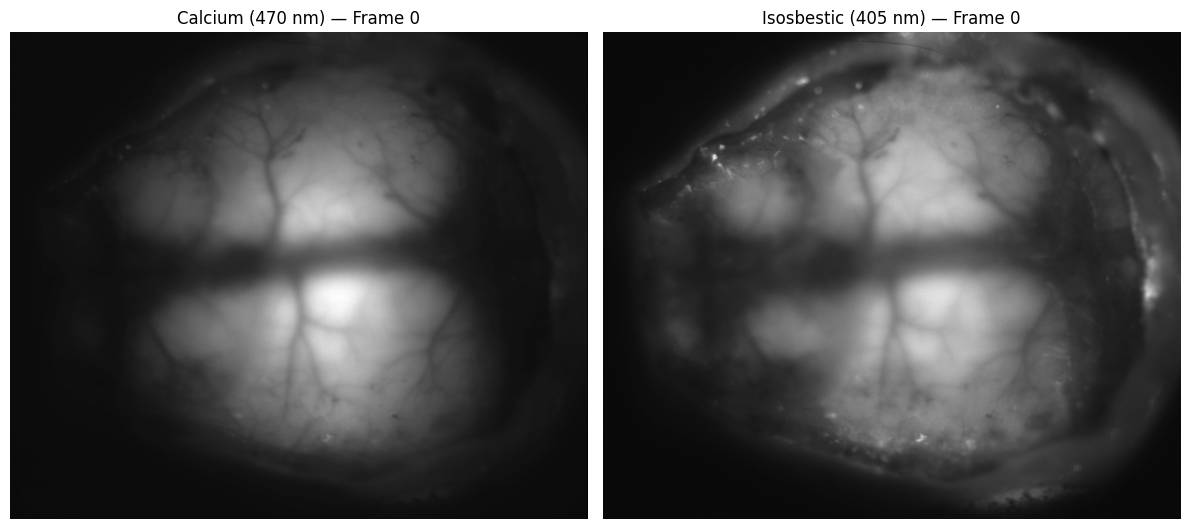

In [7]:
# Visualise first frame of each channel (lazy read — only 1 frame is downloaded)
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, dpi=100)

axes[0].imshow(calcium.data[0], cmap="gray")
axes[0].set_title("Calcium (470 nm) — Frame 0")
axes[0].axis("off")

axes[1].imshow(isosbestic.data[0], cmap="gray")
axes[1].set_title("Isosbestic (405 nm) — Frame 0")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Imaging Plane Metadata <a id="imaging-metadata"></a>

Acquisition hardware parameters (indicator, wavelengths, frame rate) are stored
in `nwbfile.imaging_planes`.

In [8]:
print("=== IMAGING PLANES ===")
print("-" * 80)
for plane_name, plane in nwbfile.imaging_planes.items():
    print(f"Plane             : {plane_name}")
    print(f"  Description     : {plane.description}")
    print(f"  Imaging rate    : {plane.imaging_rate} Hz")
    print(f"  Indicator       : {plane.indicator}")
    print(f"  Excitation λ    : {plane.excitation_lambda} nm")
    ch = plane.optical_channel[0]
    print(f"  Optical channel : {ch.name} — {ch.description}")
    print(f"  Emission λ      : {ch.emission_lambda} nm")
    print("-" * 80)

=== IMAGING PLANES ===
--------------------------------------------------------------------------------
Plane             : ImagingPlaneCalcium
  Description     : The imaging plane for calcium imaging from Blue light excitation.
  Imaging rate    : 15.0 Hz
  Indicator       : GCaMP6f
  Excitation λ    : 470.0 nm
  Optical channel : OpticalChannel — GCaMP Ca2+ bound emission (calcium signal). (Thorlabs, cat. no. M470L4)
  Emission λ      : 510.0 nm
--------------------------------------------------------------------------------
Plane             : ImagingPlaneIsosbestic
  Description     : The imaging plane for calcium imaging from Violet light excitation.
  Imaging rate    : 15.0 Hz
  Indicator       : GCaMP6f
  Excitation λ    : 405.0 nm
  Optical channel : OpticalChannel — GCaMP Ca2+ independent emission (isosbestic signal). (Thorlabs, cat. no. M405L4)
  Emission λ      : 510.0 nm
--------------------------------------------------------------------------------


---

## 4. Synchronization Signals <a id="sync"></a>

### Digital Events <a id="digital-signals"></a>

TTL / digital signals are stored as `LabeledEvents` objects.  
Each event series covers one hardware device (camera, photodiode, rotary encoder, …).

In [9]:
event_names = [name for name in nwbfile.acquisition if "Events" in name]

print("=== LABELED EVENTS ===")
print("-" * 80)
for name in event_names:
    ev = nwbfile.acquisition[name]
    print(f"  {name}")
    print(f"    {ev.description}")
    print()

=== LABELED EVENTS ===
--------------------------------------------------------------------------------
  EventsAudio
    Auditory stimulus presentation events. Marks timing of audio stimulus delivery for auditory tasks or cue presentation.

Label meanings:
  - audio_off: Audio stimulus off
  - audio_on: Audio stimulus on

  EventsBodyCamera
    Video frame acquisition times for the body camera. Each event marks when a video frame was captured by the camera, enabling temporal alignment of behavior videos with neural and task data.

Label meanings:
  - exposure_end: Camera exposure end or frame readout complete
  - frame_start: Camera frame acquisition start (frame timestamp)

  EventsFrame2ttl
    Monitor refresh events detected by photodiode for visual stimulus timing. The Frame2TTL device uses a photodiode to detect changes in screen luminance, providing precise timing of when visual stimuli are displayed on the monitor. This is essential for accurate stimulus-response latency measur

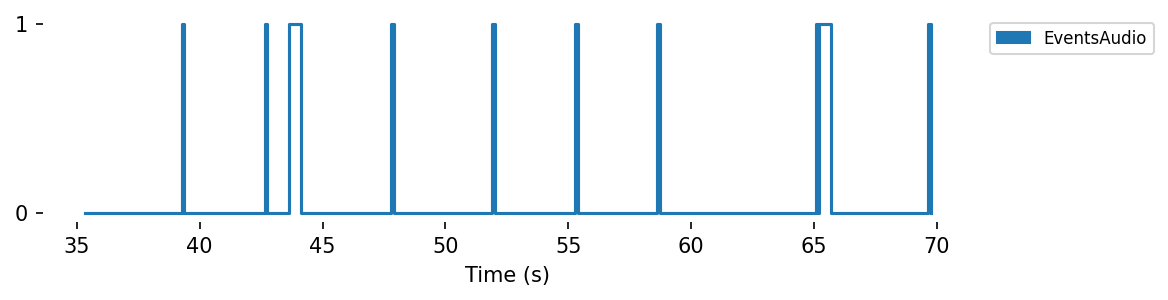

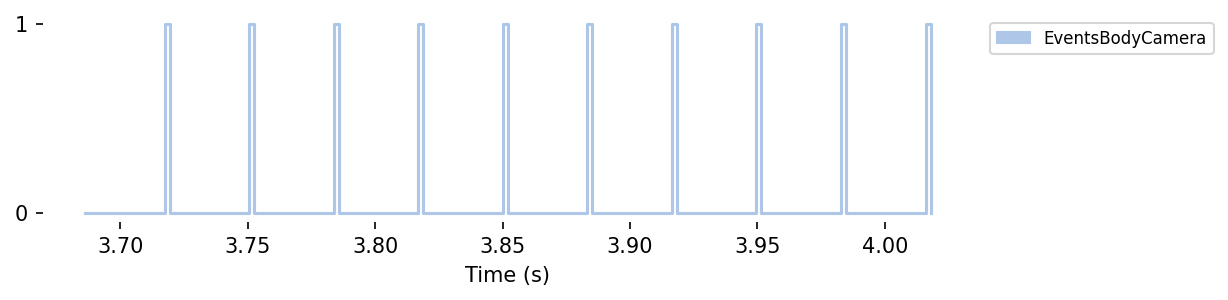

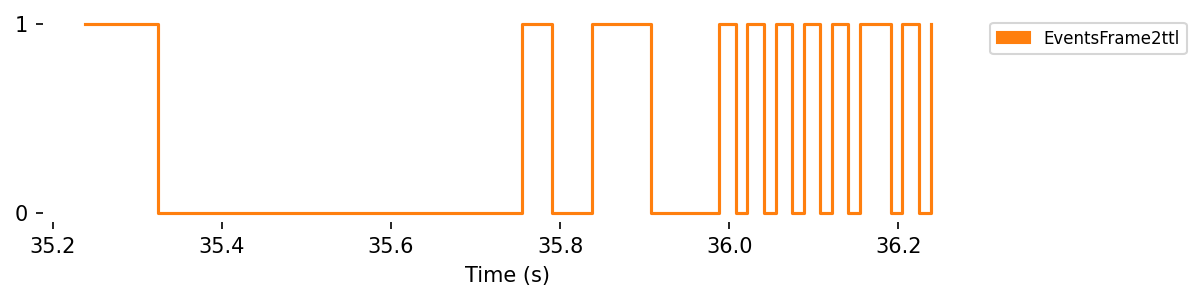

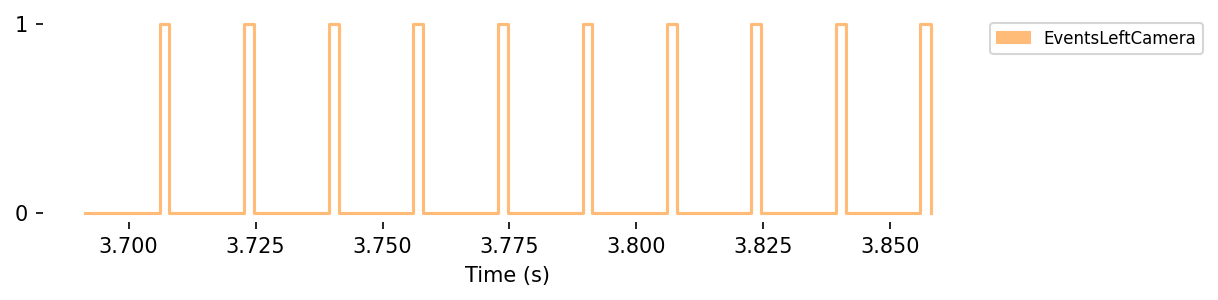

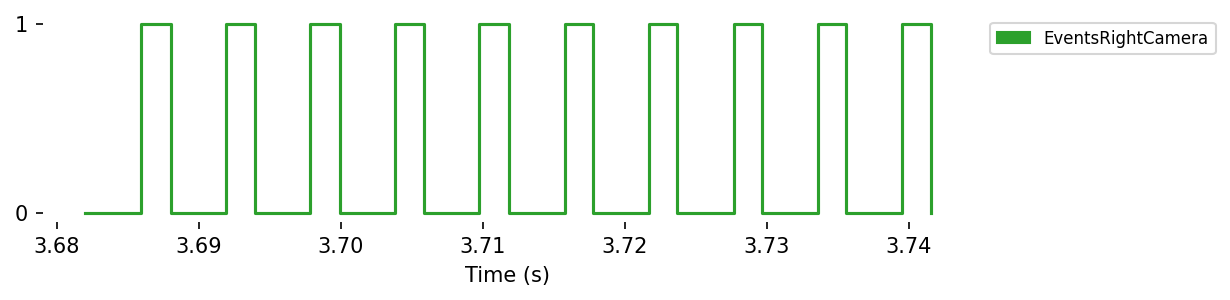

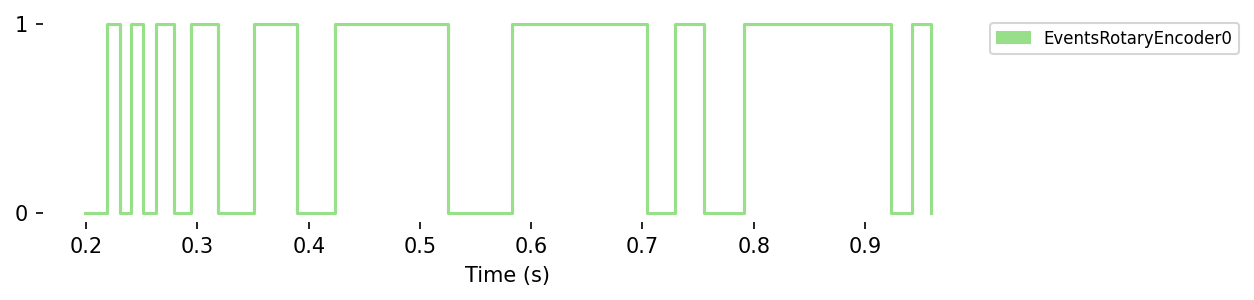

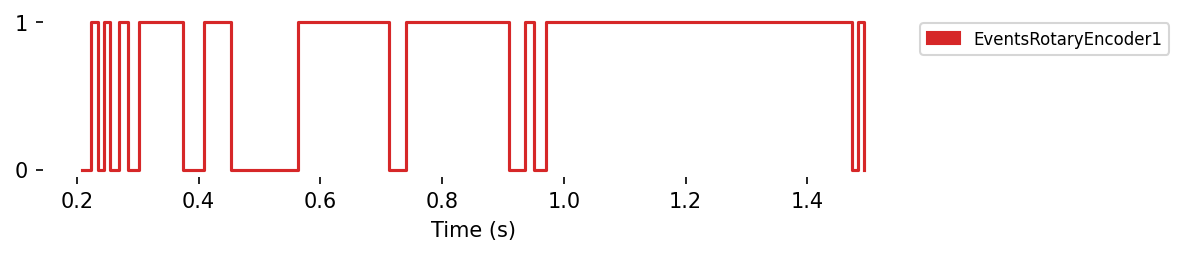

In [10]:
def plot_square_wave(times, data, ax, color, n_events=11):
    """Draw rising/falling fronts as a square wave on *ax*."""
    times = times[:n_events * 2]
    data  = data[:n_events * 2].astype(int)

    changes = np.where(np.diff(data) != 0)[0] + 1
    if changes.size == 0:
        return

    ts   = times[changes]
    prev = data[changes - 1]
    nxt  = data[changes]
    pol  = np.where((prev == 0) & (nxt == 1), 1,
           np.where((prev == 1) & (nxt == 0), -1, 0))
    mask = pol != 0
    ts, pol = ts[mask], pol[mask]

    isort = np.argsort(ts)
    ts, pol = ts[isort], pol[isort]

    f = np.tile(pol, (2, 1))
    t = np.concatenate((ts, np.r_[ts[1:], ts[-1]])).reshape(2, f.shape[1])
    y = (f.T.ravel() + 1) / 2
    ax.plot(t.T.ravel(), y, color=color, linewidth=1.5)


cmap   = plt.get_cmap("tab20")
colors = cycle([cmap(i) for i in range(cmap.N)])

for event_name in event_names:
    ev   = nwbfile.acquisition[event_name]
    col  = next(colors)
    fig, ax = plt.subplots(figsize=(8, 1.8), dpi=150)

    plot_square_wave(ev.timestamps[:], ev.data[:], ax, col)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["0", "1"])
    ax.set_frame_on(False)
    ax.set_xlabel("Time (s)")
    ax.legend(
        handles=[mpatches.Patch(color=col, label=event_name)],
        bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8,
    )

plt.tight_layout()
plt.show()

### Analog Signals <a id="analog-signals"></a>

In [11]:
analog_names = [name for name in nwbfile.acquisition if "TimeSeries" in name]

print("=== ANALOG TIME SERIES ===")
print("-" * 80)
for name in analog_names:
    ts = nwbfile.acquisition[name]
    print(f"  {name}")
    print(f"    {ts.description}")
    print(f"    rate={ts.rate} Hz, n_samples={len(ts.data)}")
    print()

=== ANALOG TIME SERIES ===
--------------------------------------------------------------------------------
  TimeSeriesBpod
    Analog signal from Bpod behavioral control system. This continuous voltage signal encodes behavioral state machine events and timestamps from the Bpod system, which controls stimulus presentation and reward delivery during tasks. The analog encoding allows precise temporal alignment between Bpod events and neural recordings.
    rate=10593.220339 Hz, n_samples=52098100



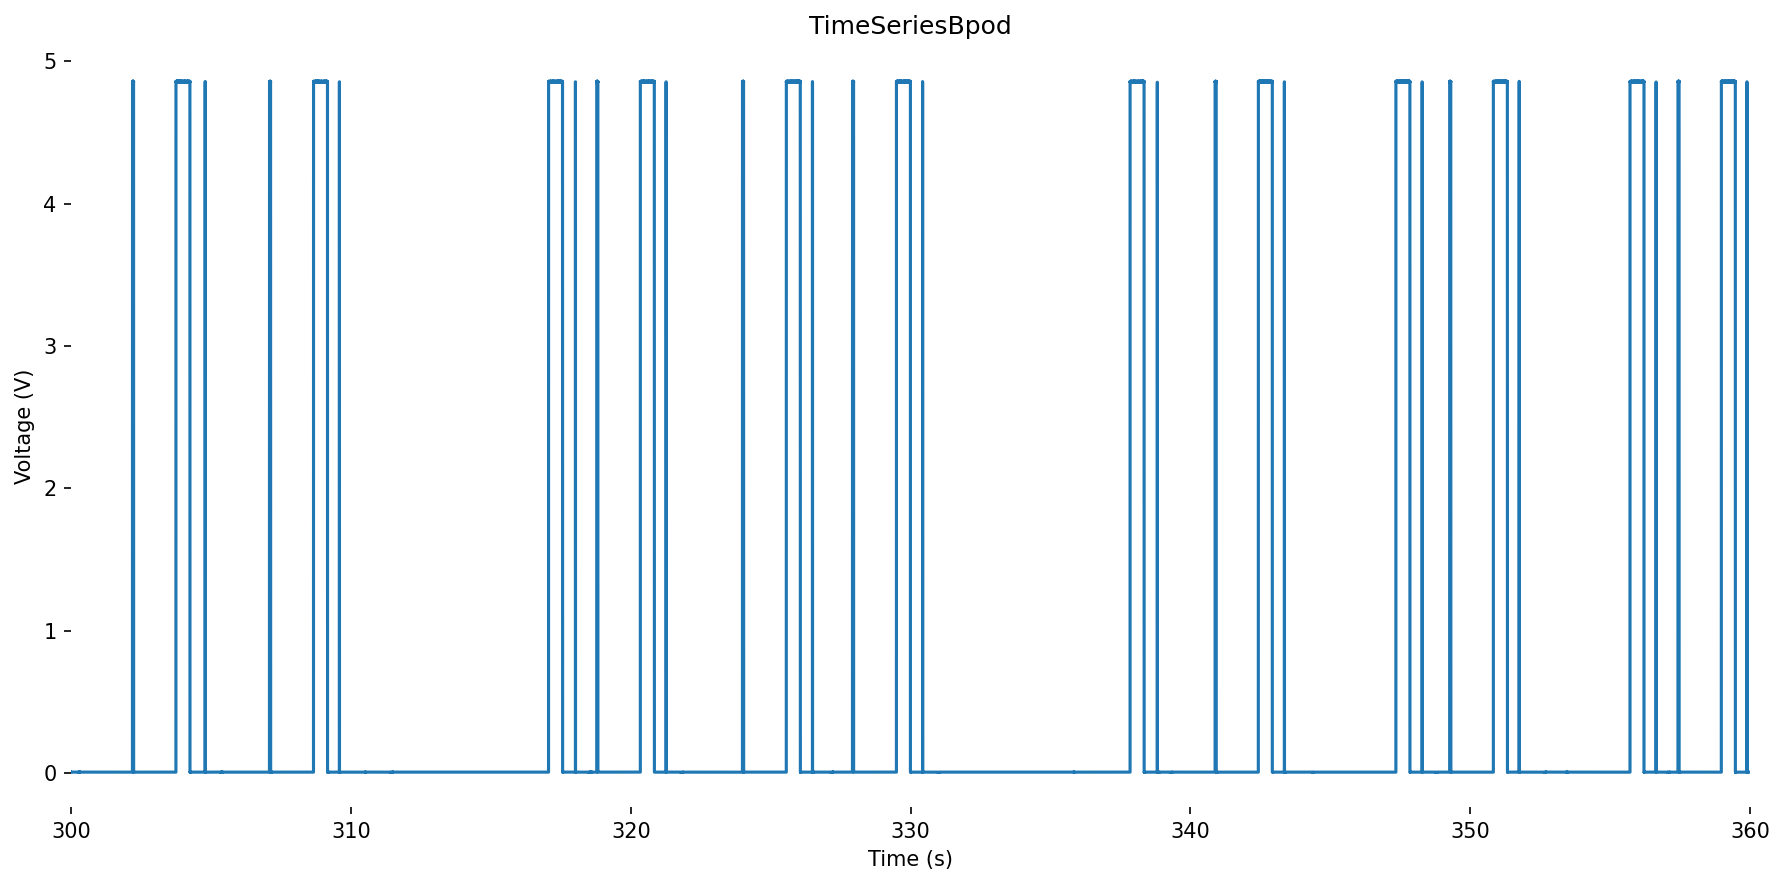

In [12]:
for signal_name in analog_names:
    ts = nwbfile.acquisition[signal_name]
    rate = ts.rate

    # Plot a 1-minute window starting at 5 min
    start_s, end_s = 5 * 60, 6 * 60
    start_idx = max(0, int((start_s - ts.starting_time) * rate))
    end_idx   = min(len(ts.data), int((end_s - ts.starting_time) * rate))

    data_v = ts.data[start_idx:end_idx] * ts.conversion
    times  = ts.starting_time + np.arange(start_idx, end_idx) / rate

    fig, ax = plt.subplots(dpi=150)
    ax.plot(times, data_v)
    ax.set_xlim(start_s, end_s)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (V)")
    ax.set_title(signal_name)
    ax.set_frame_on(False)
    plt.tight_layout()
    plt.show()

---

## 5. Behavior <a id="behavior"></a>

### Epochs <a id="epochs"></a>

Task epochs (e.g. `active_task`, `passive_task`) are stored in `nwbfile.epochs`.

In [13]:
nwbfile.epochs

,start_time,stop_time,protocol_type,epoch_description
id,,,,
0,0.000000,3769.991275,task,Active behavioral task period. The mouse performs a decision-making task where it must turn a wheel to move a visual stimulus (Gabor patch) to the center of the screen. Correct responses are rewarded with water; incorrect responses trigger white noise feedback. The trials table contains detailed timing and outcome data for each trial during this epoch.
1,3769.991275,4918.060357,passive,"Passive stimulus replay period. Visual and auditory stimuli are presented while the mouse is head-fixed but not performing any task. This epoch includes: (1) replay of task-relevant stimuli (Gabor patches at various contrasts and positions), (2) sparse noise stimuli for receptive field mapping, and (3) natural movie clips. Used for characterizing sensory responses independent of task engagement."


### Raw Video <a id="raw-video"></a>

Behavior cameras are stored as `ImageSeries` with external `.mp4` files.  
The timestamps in the NWB file allow alignment with imaging and sync signals.

In [14]:
video_names = [name for name in nwbfile.acquisition if "Video" in name]

print("=== BEHAVIOR VIDEOS ===")
print("-" * 80)
for name in video_names:
    vid = nwbfile.acquisition[name]
    print(f"  {name}")
    print(f"    Description  : {vid.description}")
    print(f"    External file: {vid.external_file[:]}")
    print(f"    N timestamps : {len(vid.timestamps)}")
    print()

=== BEHAVIOR VIDEOS ===
--------------------------------------------------------------------------------
  VideoBodyCamera
    Description  : Raw video from camera recording behavioral and task events.
    External file: ['./sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_ecephys+image\\sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_VideoBodyCamera.mp4']
    N timestamps : 148044

  VideoLeftCamera
    Description  : Raw video from camera recording behavioral and task events.
    External file: ['./sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_ecephys+image\\sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_VideoLeftCamera.mp4']
    N timestamps : 294962

  VideoRightCamera
    Description  : Raw video from camera recording behavioral and task events.
    External file: ['./sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_ecephys+image\\sub-CSK-im-009_ses-2864dca1-38d8-464c-9777-f6fdfd5e63b5_VideoRightCamera.mp4']
    N timestamps : 825367

